In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch 

In [9]:
## comparaison des grilles des NetCDF PECD et ERA5 (version Spirit)

In [10]:
era = xr.open_dataarray("F:/ERA5_2000/t2m.200001.as1e5.GLOBAL_025.nc")
pecd = xr.open_dataarray("F:/PECD_2000/H_ERA5_ECMW_T639_TA-_0002m_Pecd_025d_S200001010000_E200012312300_INS_MAP_01h_NA-_noc_org_NA_NA---_NA---_NA---_PECD4.2_fv1.nc")

In [11]:
lon_era = era.longitude.values
lon_pecd = pecd.longitude.values
lat_era = era.latitude.values
lat_pecd = pecd.latitude.values

In [12]:
def tous_points_dans_autre(petite, grande, tol=1e-6):
    # Pour chaque point de "petite", vérifier qu'il existe un point proche dans "grande"
    for v in petite:
        if v < 0 :
            v += 360
        if not np.any(np.isclose(v, grande, atol=tol)):
            return str(v) + " n'est pas dans l'autre grille"
    return True

lon_included = tous_points_dans_autre(lon_pecd, lon_era)
lat_included = tous_points_dans_autre(lat_pecd, lat_era)


print("Tous les longitudes de la grille 2 sont dans la grille 1:", lon_included)
print("Toutes les latitudes de la grille 2 sont dans la grille 1:", lat_included)

Tous les longitudes de la grille 2 sont dans la grille 1: True
Toutes les latitudes de la grille 2 sont dans la grille 1: True


In [13]:
lon_pecd_centered = np.where(lon_pecd < 0, lon_pecd + 360, lon_pecd)
lat_pecd_centered = np.where(lat_pecd < 0, lat_pecd + 360, lat_pecd)

In [14]:
def temperatures_egales(petite_nc, grande_nc, tol=1):
    list_dates = []
    array_diff = []
    for d in pecd.where(pecd.time.dt.month == 1, drop=True).time.values:
        t_pecd = petite_nc.sel(time=d)
        t_era = grande_nc.sel(time=d, method='nearest').sel(longitude=lon_pecd_centered, latitude=lat_pecd_centered, method='nearest', tolerance=1e-6)
        if not np.all(np.isclose(t_pecd.values, t_era.values, atol=tol)):
            list_dates.append(d)
        array_diff.append(t_era.values - t_pecd.values)
    return list_dates, array_diff

In [15]:
dates, diff = temperatures_egales(pecd, era)

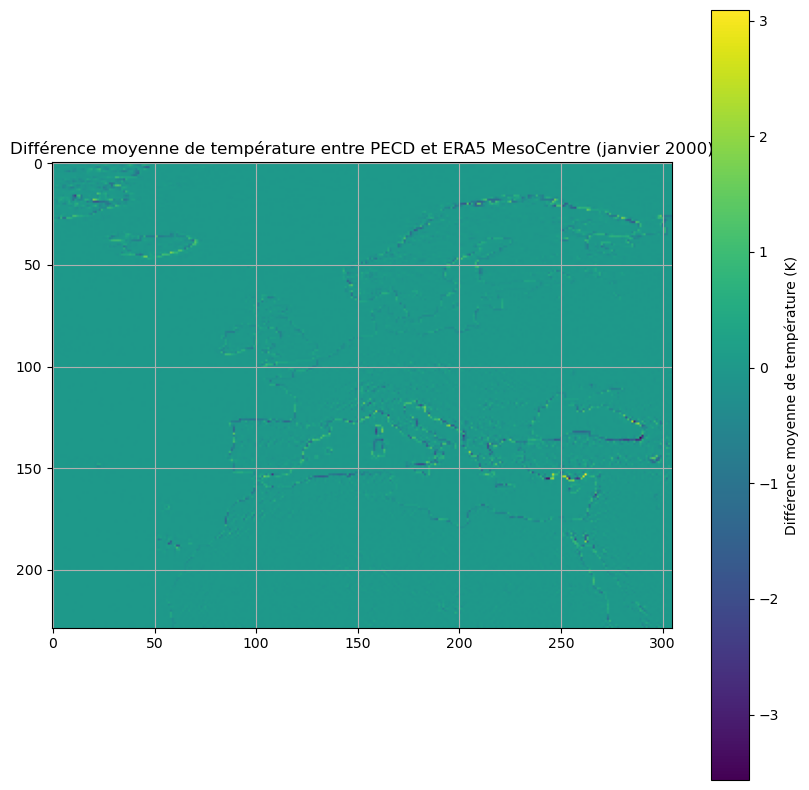

In [16]:
plt.figure(figsize = (10, 10))
im = plt.imshow(np.sum(diff, axis=0)/len(diff))
plt.colorbar(im, label='Différence moyenne de température (K)')
plt.title('Différence moyenne de température entre PECD et ERA5 MesoCentre (janvier 2000)')
plt.grid()
plt.show()  

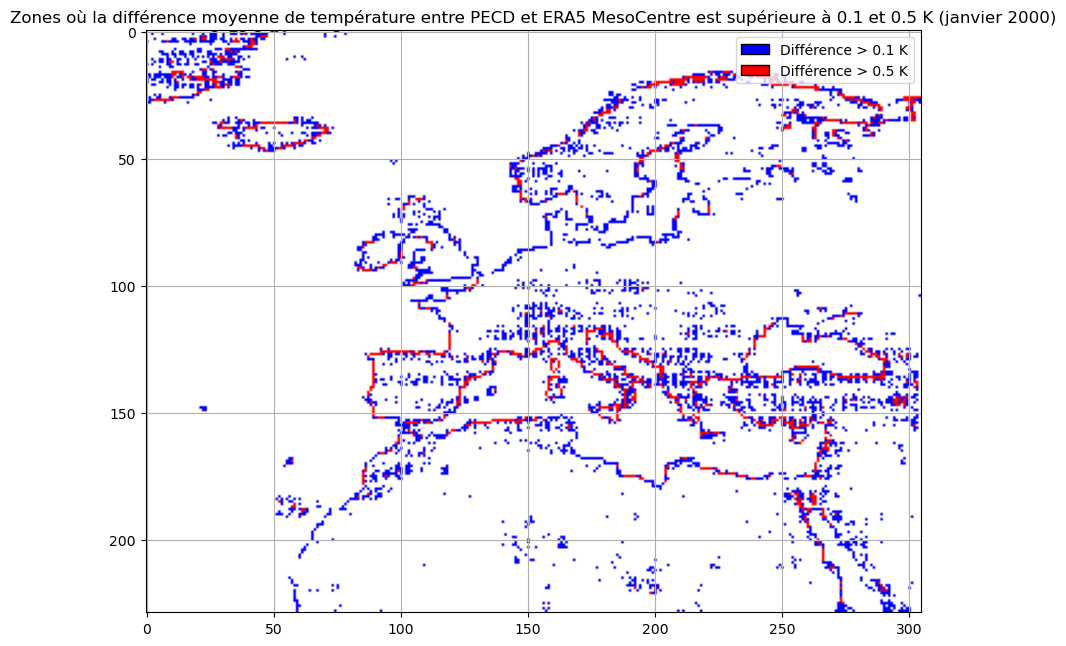

In [17]:
mean_diff = np.abs(np.sum(diff, axis=0) / len(diff))

img = (mean_diff > 0.1).astype(int) + (mean_diff > 0.5).astype(int)

plt.figure(figsize=(10, 10))

cmap = ListedColormap(['white', 'blue', 'red'])
im = plt.imshow(img, cmap=cmap)

plt.title("Zones où la différence moyenne de température entre "
          "PECD et ERA5 MesoCentre est supérieure à 0.1 et 0.5 K (janvier 2000)")

legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Différence > 0.1 K'),
    Patch(facecolor='red', edgecolor='black', label='Différence > 0.5 K')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid()
plt.show()

In [18]:
## comparaison des grilles des NetCDF PECD et ERA5 (version du CDS)

In [19]:
era = xr.open_dataarray("F:/ERA5_2000/t2m.200001.CDS_version.GLOBAL_025.nc")
pecd = xr.open_dataarray("F:/PECD_2000/H_ERA5_ECMW_T639_TA-_0002m_Pecd_025d_S200001010000_E200012312300_INS_MAP_01h_NA-_noc_org_NA_NA---_NA---_NA---_PECD4.2_fv1.nc")

In [20]:
lon_era = era.longitude.values
lon_pecd = pecd.longitude.values
lat_era = era.latitude.values
lat_pecd = pecd.latitude.values

In [21]:
def tous_points_dans_autre(petite, grande, tol=1e-6):
    # Pour chaque point de "petite", vérifier qu'il existe un point proche dans "grande"
    for v in petite:
        if v < 0 :
            v += 360
        if not np.any(np.isclose(v, grande, atol=tol)):
            return str(v) + " n'est pas dans l'autre grille"
    return True

lon_included = tous_points_dans_autre(lon_pecd, lon_era)
lat_included = tous_points_dans_autre(lat_pecd, lat_era)


print("Tous les longitudes de la grille 2 sont dans la grille 1:", lon_included)
print("Toutes les latitudes de la grille 2 sont dans la grille 1:", lat_included)

Tous les longitudes de la grille 2 sont dans la grille 1: True
Toutes les latitudes de la grille 2 sont dans la grille 1: True


In [22]:
lon_pecd_centered = np.where(lon_pecd < 0, lon_pecd + 360, lon_pecd)
lat_pecd_centered = np.where(lat_pecd < 0, lat_pecd + 360, lat_pecd)

In [23]:
def temperatures_egales(petite_nc, grande_nc, tol=1):
    list_dates = []
    array_diff = []
    for d in pecd.where(pecd.time.dt.month == 1, drop=True).time.values:
        t_pecd = petite_nc.sel(time=d)
        t_era = grande_nc.sel(valid_time=d, method='nearest').sel(longitude=lon_pecd_centered, latitude=lat_pecd_centered, method='nearest', tolerance=1e-6)
        if not np.all(np.isclose(t_pecd.values, t_era.values, atol=tol)):
            list_dates.append(d)
            plt.imshow(t_era.values - t_pecd.values)
            break
        array_diff.append(t_era.values - t_pecd.values)
    return list_dates, array_diff

In [24]:
dates, diff = temperatures_egales(pecd, era)

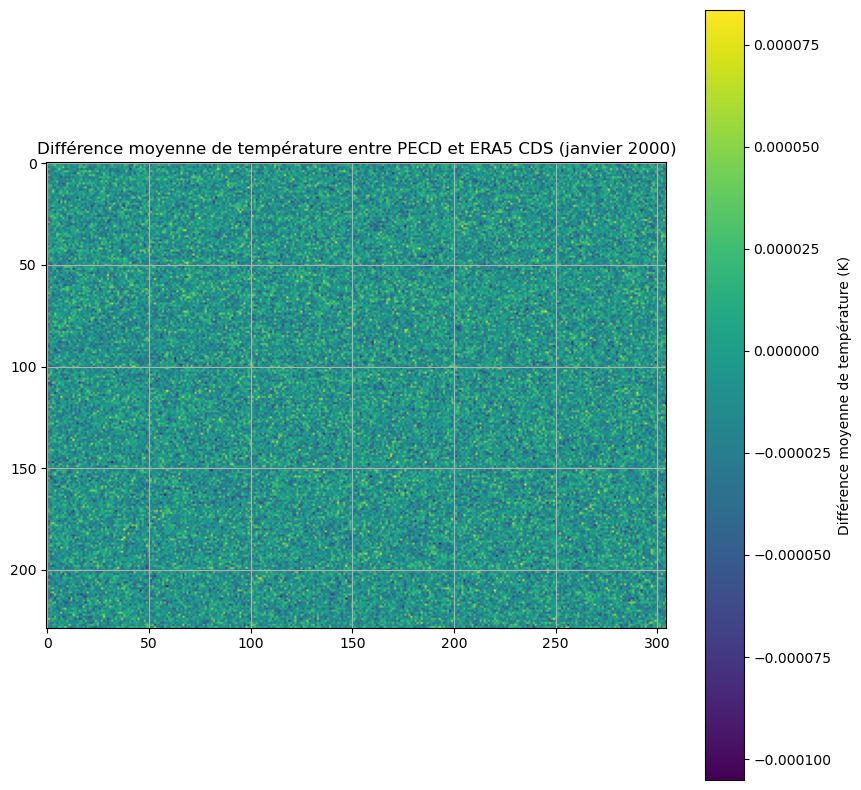

In [25]:
plt.figure(figsize = (10, 10))
im = plt.imshow(np.sum(diff, axis=0)/len(diff))
plt.colorbar(im, label='Différence moyenne de température (K)')
plt.title('Différence moyenne de température entre PECD et ERA5 CDS (janvier 2000)')
plt.grid()
plt.show()

In [2]:
## la version utilisée dans la PECD est celle présente sur le CDS, et non celle de Spirit (en date du 09/04/2025)

In [3]:
## comparaison ERA5 - CDS et RA5 - Spirit

In [2]:
era_cds_2000 = xr.open_dataarray("F:/ERA5_2000/t2m.200001.CDS_version.GLOBAL_025.nc")
era_meso_2000 = xr.open_dataarray("F:/t2m.200001.as1e5.GLOBAL_025.nc")


era_cds_2024 = xr.open_dataarray("F:/ERA5_2000/t2m.202401.CDS_version.GLOBAL_025.nc")
era_meso_2024 = xr.open_dataarray("F:/ERA5_2000/t2m.202401.as1e5.GLOBAL_025.nc")

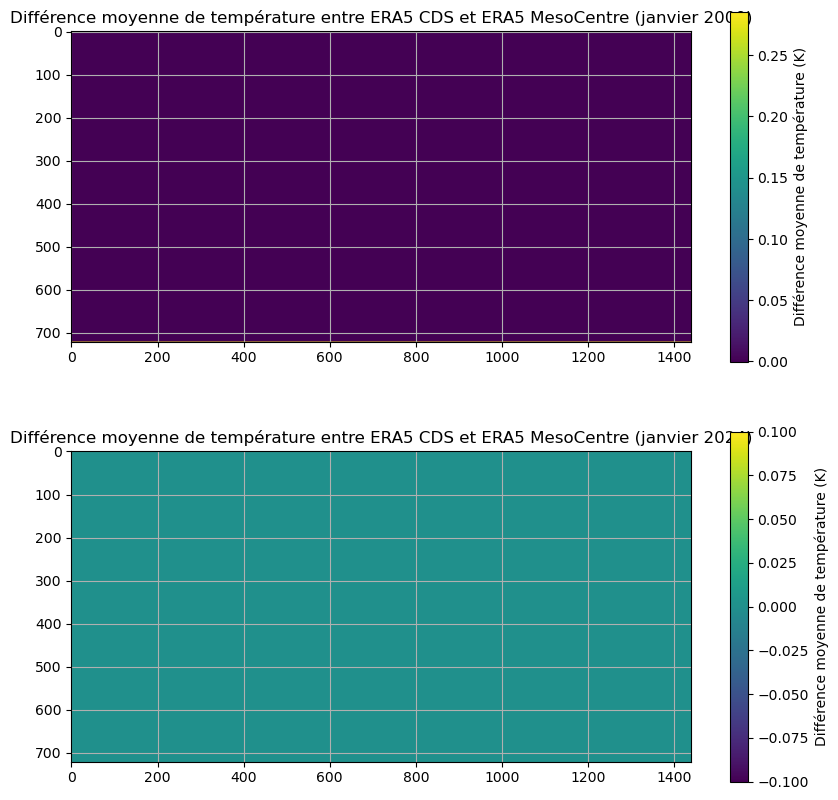

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
img = ax[0].imshow(np.mean(era_cds_2000.values - era_meso_2000.values, axis=0))
fig.colorbar(img, ax = ax[0], label='Différence moyenne de température (K)')
ax[0].set_title('Différence moyenne de température entre ERA5 CDS et ERA5 MesoCentre (janvier 2000)')
ax[0].grid()

img = ax[1].imshow(np.mean(era_cds_2024.values - era_meso_2024.values, axis=0))
fig.colorbar(img, ax = ax[1], label='Différence moyenne de température (K)')  
ax[1].set_title('Différence moyenne de température entre ERA5 CDS et ERA5 MesoCentre (janvier 2024)')
ax[1].grid()

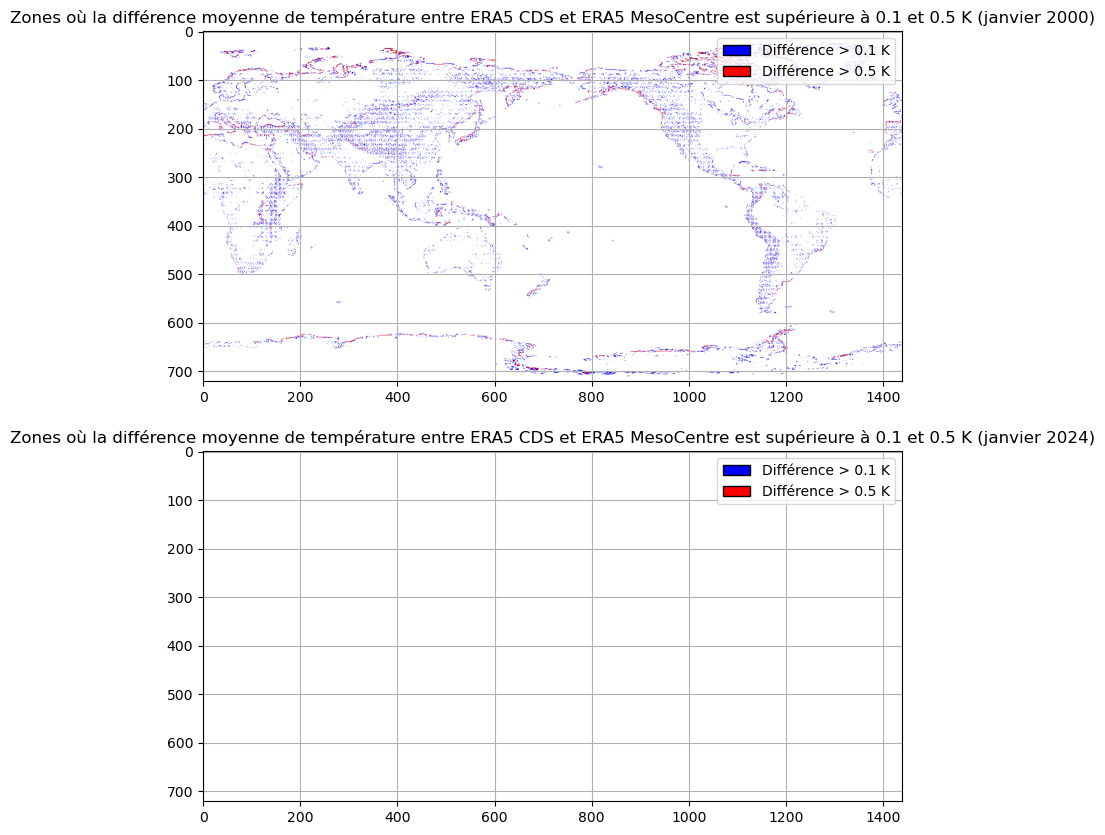

In [7]:
mean_diff = np.mean(era_cds_2000.values - era_meso_2000.values, axis=0)

img = (mean_diff > 0.1).astype(int) + (mean_diff > 0.5).astype(int)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))

cmap = ListedColormap(['white', 'blue', 'red'])
im = ax[0].imshow(img, cmap=cmap)

ax[0].set_title("Zones où la différence moyenne de température entre "
                 "ERA5 CDS et ERA5 MesoCentre est supérieure à 0.1 et 0.5 K (janvier 2000)")

legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Différence > 0.1 K'),
    Patch(facecolor='red', edgecolor='black', label='Différence > 0.5 K')
]
ax[0].legend(handles=legend_elements, loc='upper right')

ax[0].grid()

mean_diff = np.mean(era_cds_2024.values - era_meso_2024.values, axis=0)

img = (mean_diff > 0.1).astype(int) + (mean_diff > 0.5).astype(int)

cmap = ListedColormap(['white', 'blue', 'red'])
im = ax[1].imshow(img, cmap=cmap)

ax[1].set_title("Zones où la différence moyenne de température entre "
                 "ERA5 CDS et ERA5 MesoCentre est supérieure à 0.1 et 0.5 K (janvier 2024)")

legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Différence > 0.1 K'),
    Patch(facecolor='red', edgecolor='black', label='Différence > 0.5 K')
]
ax[1].legend(handles=legend_elements, loc='upper right')

ax[1].grid()


plt.show()